In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [19]:
X, y = load_iris(return_X_y=True, as_frame=True)

In [20]:
X.sample(n=5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
106,4.9,2.5,4.5,1.7
32,5.2,4.1,1.5,0.1
100,6.3,3.3,6.0,2.5
116,6.5,3.0,5.5,1.8
12,4.8,3.0,1.4,0.1


In [21]:
y.sample(n=5)

135    2
6      0
143    2
91     1
133    2
Name: target, dtype: int64

In [22]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


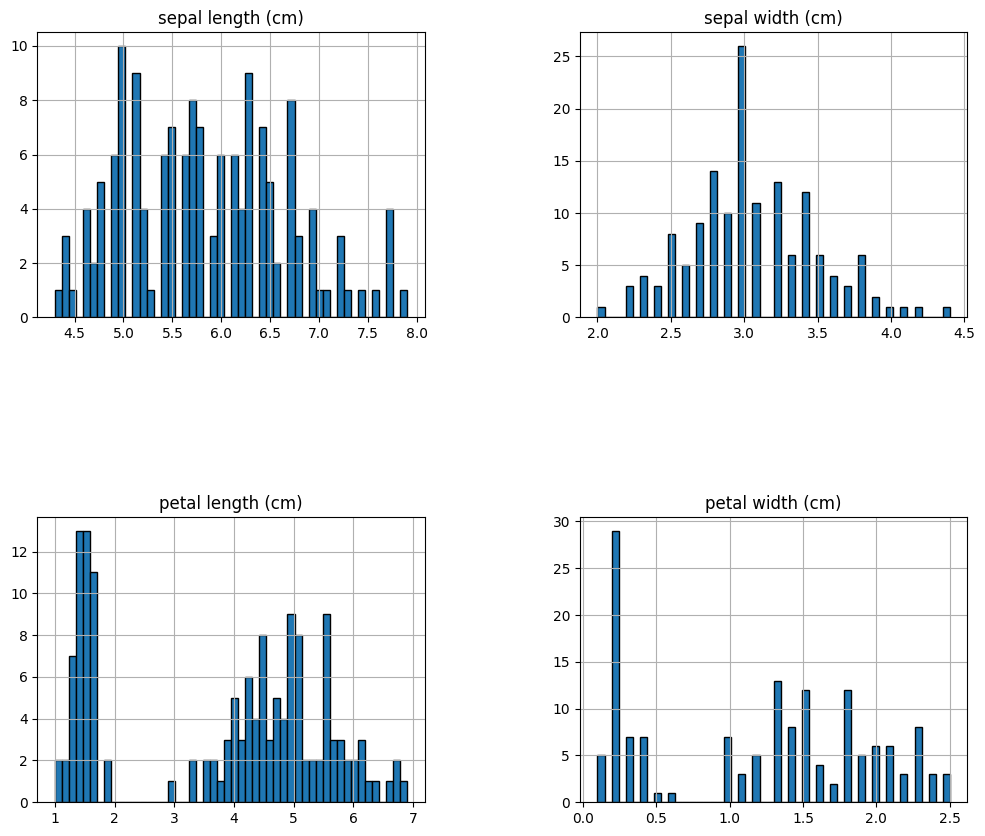

In [23]:
X.hist(figsize=(12, 10), bins=50, edgecolor='black')
plt.subplots_adjust(hspace=0.7, wspace=0.4)

In [24]:
X.corr(numeric_only=True)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


<Axes: >

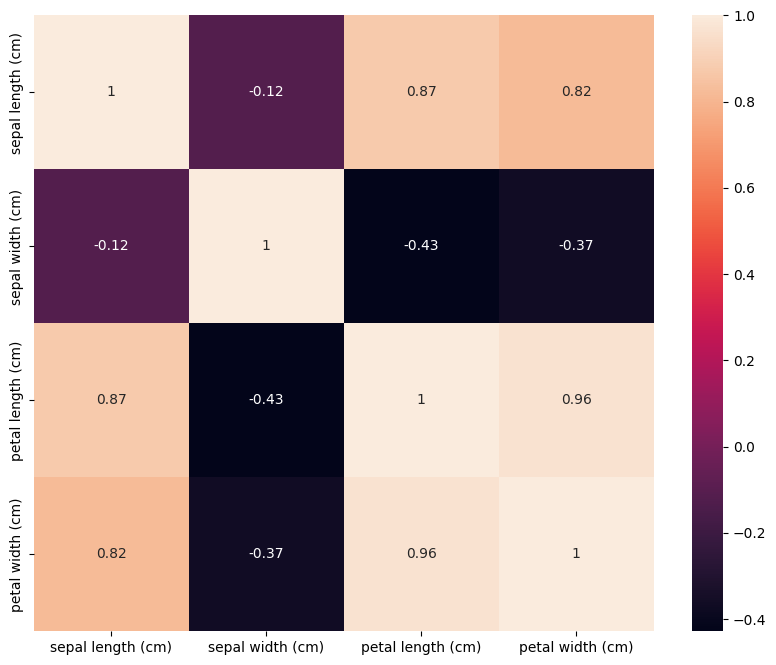

In [25]:
corr_matrix = X.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True)

Splitting the dataset:

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [ ]:
#making a pipeline

pipe = Pipeline(
    [('std_scale', StandardScaler()),
     ('model', SVC(kernel='rbf', C=2, gamma=0.1))]
)

pipe.fit(X=X_train, y=y_train)
print("Cross val score: ", np.mean(cross_val_score(pipe, X_train.to_numpy(), y_train, cv=10)))
print("Cross val score std deviation: ", cross_val_score(pipe, X_train.to_numpy(), y_train, cv=10).std())

y_pred = pipe.predict(X=X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.88      0.93         8
           2       0.89      1.00      0.94         8

    accuracy                           0.97        30
   macro avg       0.96      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30

Cross val score:  0.9733333333333334
Cross val score std deviation:  0.04422166387140532


Hyperparameter Tuning:

In [44]:
params = {
    'model__C': np.linspace(start=0, stop=10, num=20, dtype=int),
    'model__gamma': np.linspace(start=0, stop=10, num=20, dtype=int),
}

grid = GridSearchCV(pipe, param_grid=params, cv = 5, scoring = 'accuracy')

In [45]:
grid.fit(X_train, y_train)
print(grid.best_score_, grid.best_params_)

0.9666666666666668 {'model__C': np.int64(7), 'model__gamma': np.int64(1)}


/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
200 fits failed out of a total of 2000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
200 fits failed with the following error:
Traceback (most recent call last):
  File "/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/pipeline.py", line 6

In [48]:
np.mean(cross_val_score(grid, X_train, y_train, cv=5))

/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
200 fits failed out of a total of 2000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
200 fits failed with the following error:
Traceback (most recent call last):
  File "/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/vhvhs/ML/.venv/lib64/python3.14/site-packages/sklearn/pipeline.py", line 6

np.float64(0.95)

In [55]:
y_pred = grid.predict(X=X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       1.00      0.88      0.93         8
           2       0.80      1.00      0.89         8

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.95      0.93      0.94        30

